# **Detection of Coronary Heart Disease Using ECG Images with Explainable Artificial Intelligence**

Dataset - (https://www.kaggle.com/datasets/evilspirit05/ecg-analysis/data)

## Dataset Downloading

In [ ]:
pip install kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nuthannavuluri","key":"0bb6aac5733e00d197c854cb63f786bc"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d evilspirit05/ecg-analysis
!unzip ecg-analysis.zip
import os
os.listdir()

Dataset URL: https://www.kaggle.com/datasets/evilspirit05/ecg-analysis
License(s): MIT
100% 0.99G/1.00G [00:07<00:00, 88.1MB/s]
100% 1.00G/1.00G [00:07<00:00, 140MB/s] 
Archive:  ecg-analysis.zip
  inflating: ecg data old version/ecg data old version/test/ECG Images of Myocardial Infarction Patients (240x12=2880)/MI(1).jpg  
  inflating: ecg data old version/ecg data old version/test/ECG Images of Myocardial Infarction Patients (240x12=2880)/MI(10).jpg  
  inflating: ecg data old version/ecg data old version/test/ECG Images of Myocardial Infarction Patients (240x12=2880)/MI(100).jpg  
  inflating: ecg data old version/ecg data old version/test/ECG Images of Myocardial Infarction Patients (240x12=2880)/MI(101).jpg  
  inflating: ecg data old version/ecg data old version/test/ECG Images of Myocardial Infarction Patients (240x12=2880)/MI(102).jpg  
  inflating: ecg data old version/ecg data old version/test/ECG Images of Myocardial Infarction Patients (240x12=2880)/MI(103).jpg  
  inflati

['.config',
 'kaggle.json',
 'ecg-analysis.zip',
 'ecg data old version',
 'ecg_data_new_version',
 'sample_data']

## Data Pre-Processing

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import pandas as pd
import seaborn as sns

In [ ]:
dataset_path = "/content/ecg_data_new_version/ecg data new version"

In [ ]:
os.listdir(dataset_path)

['post_mi_history_ecg_images',
 'myocardial_infarction_ecg_images',
 'normal_ecg_images',
 'abnormal_heartbeat_ecg_images']

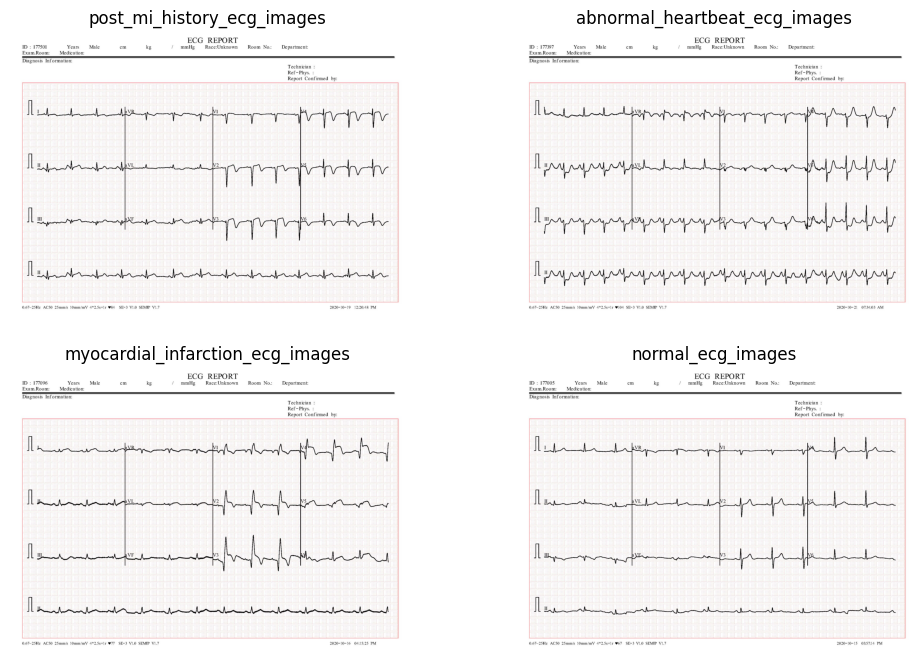

In [ ]:
classes = [
    'post_mi_history_ecg_images',
    'abnormal_heartbeat_ecg_images',
    'myocardial_infarction_ecg_images',
    'normal_ecg_images'
]

plt.figure(figsize=(12,8))

for i, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)

    # get first image from folder
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.show()

## EDA

In [ ]:
for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    count = len(os.listdir(class_path))
    print(f"{class_name}: {count} images")

post_mi_history_ecg_images: 172 images
abnormal_heartbeat_ecg_images: 233 images
myocardial_infarction_ecg_images: 239 images
normal_ecg_images: 284 images


In [ ]:
class_counts = {}

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    class_counts[class_name] = len(os.listdir(class_path))

print(class_counts)

{'post_mi_history_ecg_images': 172, 'abnormal_heartbeat_ecg_images': 233, 'myocardial_infarction_ecg_images': 239, 'normal_ecg_images': 284}


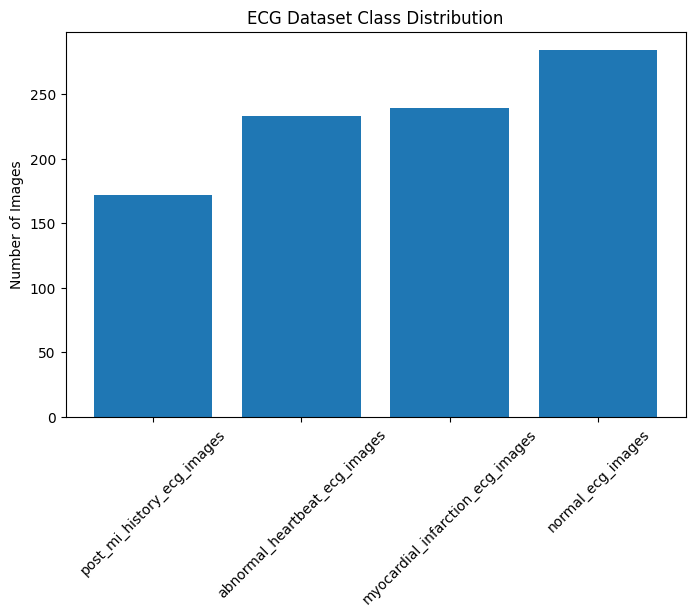

In [ ]:
import matplotlib.pyplot as plt

names = list(class_counts.keys())
values = list(class_counts.values())

plt.figure(figsize=(8,5))
plt.bar(names, values)
plt.xticks(rotation=45)
plt.title("ECG Dataset Class Distribution")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
widths = []
heights = []

for class_name in classes:

    class_path = os.path.join(dataset_path, class_name)

    for img in os.listdir(class_path)[:50]:
        img_path = os.path.join(class_path, img)
        image = cv2.imread(img_path)

        h, w, _ = image.shape
        heights.append(h)
        widths.append(w)

print("Average Height:", np.mean(heights))
print("Average Width:", np.mean(widths))

Average Height: 1572.0
Average Width: 2213.0


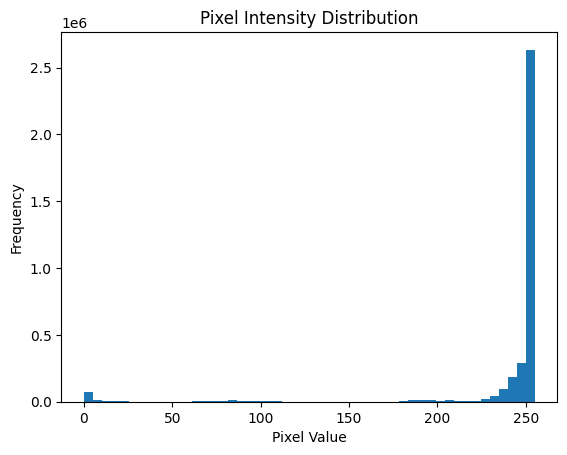

In [ ]:
sample_class = classes[0]
sample_path = os.path.join(dataset_path, sample_class)
img_name = os.listdir(sample_path)[0]

image = cv2.imread(os.path.join(sample_path, img_name), 0)

plt.hist(image.ravel(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

### **Edge Detection Analysis**

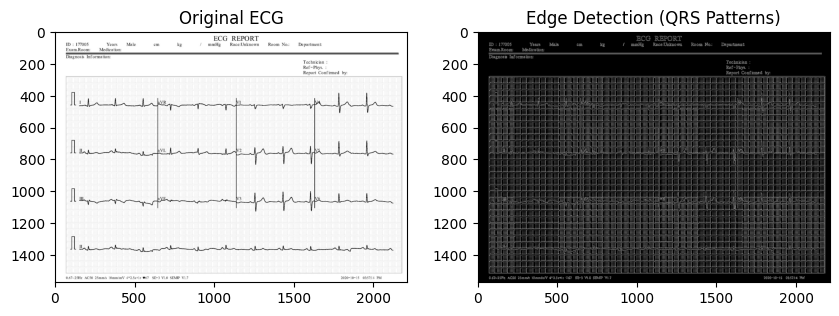

In [ ]:
class_name = "normal_ecg_images"
class_path = os.path.join(dataset_path, class_name)

img_name = os.listdir(class_path)[0]
img_path = os.path.join(class_path, img_name)

image = cv2.imread(img_path, 0)

edges = cv2.Canny(image, 100, 200)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original ECG")

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection (QRS Patterns)")

plt.show()

### **ECG Texture Analysis**

In [ ]:
from skimage.feature import graycomatrix, graycoprops

image = cv2.imread(img_path, 0)

glcm = graycomatrix(image, [1], [0], 256, symmetric=True, normed=True)

contrast = graycoprops(glcm, 'contrast')[0,0]
energy = graycoprops(glcm, 'energy')[0,0]
homogeneity = graycoprops(glcm, 'homogeneity')[0,0]

print("Contrast:", contrast)
print("Energy:", energy)
print("Homogeneity:", homogeneity)

Contrast: 1337.7070420882624
Energy: 0.46023682803243215
Homogeneity: 0.5230110735659111


### **Class Distribution Pie Chart**

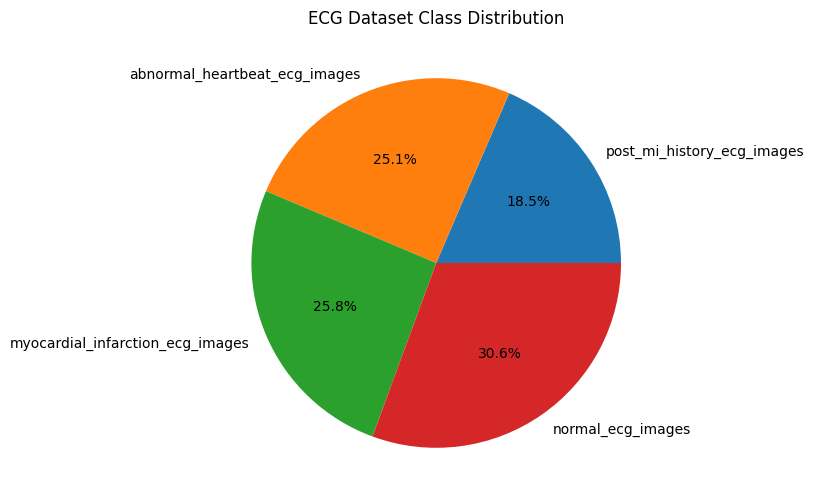

In [ ]:
import matplotlib.pyplot as plt

labels = classes
sizes = [len(os.listdir(os.path.join(dataset_path,c))) for c in classes]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("ECG Dataset Class Distribution")
plt.show()

## Image preprocessing

### **Remove Corrupted Images**

In [ ]:
for class_name in classes:

    class_path = os.path.join(dataset_path, class_name)

    for img in os.listdir(class_path):

        img_path = os.path.join(class_path, img)

        try:
            image = cv2.imread(img_path)
            if image is None:
                os.remove(img_path)
        except:
            os.remove(img_path)

print("Corrupted images removed")

Corrupted images removed


### **Data Augmentation**